<a href="https://colab.research.google.com/github/martinthuriaux/Auto-Interp-Causal-Validation/blob/main/04_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/martinthuriaux/CNN-Watch-vs-Do/blob/main/04_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — The watching test and the doing test (Stage 4 of PLAN.md, week 4)

Two grades per detector:

**Watching score** — does the label predict *firing*? Rank the held-out images by CLIP-similarity
to the label, rank them by the detector's actual firing, measure agreement (AUC). Scored on the
locked-away ImageNetV2 holdout half, so the label is graded on images it was NOT chosen from.

**Doing score** — does the label predict *damage*? Mean-ablate the detector, measure the per-class
accuracy drop over the evaluation set (the damage profile), then measure whether the damage lands
on classes semantically close to the label (CLIP text similarity). Also records raw importance
(total accuracy drop) separately.

**Gate A pilot first:** we run the doing test on one stage (256 units) before committing to all
1,920. If single-unit ablation does nothing for >90% of pilot units (redundancy), we pivot to
group ablation — decided here, before seeing the full results.

**Reused:** CLIP image embeddings (03), text embeddings (03), the activation matrix (03),
the frozen holdout split (01). **New caches:** watching scores, damage matrix, doing scores.

## 0. Bootstrap + guards

In [1]:
import os, json, hashlib, glob, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch

assert torch.cuda.is_available(), "no GPU — Runtime > Change runtime type > T4"
device = "cuda"

from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/cnn_watch_vs_do")
RESULTS = PROJECT_ROOT / "results"
DATA = Path("/content/data"); DATA.mkdir(exist_ok=True)
(RESULTS / "scores").mkdir(parents=True, exist_ok=True)

CONFIG = json.load(open(RESULTS / "config.json"))
CONFIG_HASH = hashlib.sha256(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:12]
STAGES = CONFIG["stages"]
STAGE_C = dict(zip(STAGES, CONFIG["expected_stage_channels"]))
index = json.load(open(RESULTS / "activations" / "image_index.json"))
N_IMAGES = len(index)

unit_order = [(s, c) for s in STAGES for c in range(STAGE_C[s])]
unit_col = {uc: j for j, uc in enumerate(unit_order)}
print("config hash:", CONFIG_HASH, "| units:", len(unit_order))


Mounted at /content/drive
config hash: 804f511675ac | units: 1920


## 1. Load the reused artifacts from week 3

The activation matrix (firing), CLIP image + text embeddings, the vocabulary, and both
label tables. All were cached in 03; nothing is recomputed.

In [2]:
A_max   = np.load(RESULTS / "embeddings" / "act_max_matrix.npy")     # [N_img, N_units] firing
img_emb = np.load(RESULTS / "embeddings" / "clip_img_emb.npy")       # [N_img, D] CLIP image
txt_emb = np.load(RESULTS / "embeddings" / "clip_txt_emb.npy")       # [V, D] CLIP word
vocab   = [w.strip() for w in open(RESULTS / "labels" / "vocab_20k.txt") if w.strip()]
dfA     = pd.read_json(RESULTS / "labels" / "labels_A.json")

# holdout mask: the ImageNetV2 half locked away in 01 (never used to pick labels)
holdout_ids = np.array([e["image_id"] for e in index if e.get("inv2_role") == "holdout"])
print(f"activation {A_max.shape}, img_emb {img_emb.shape}, txt_emb {txt_emb.shape}")
print(f"holdout images (for watching test): {len(holdout_ids)}")


activation (31178, 1920), img_emb (31178, 512), txt_emb (20000, 512)
holdout images (for watching test): 5000


## 2. Watching test — does the label predict firing on held-out images?

For each unit: embed its label, score each holdout image by similarity to the label, and ask
how well that similarity separates the unit's *top-firing* holdout images from the rest —
i.e. AUC of (label-similarity) as a classifier for (unit fired hard: top 1%). AUC 0.5 = label
predicts firing no better than chance; 1.0 = perfect. Vectorised over all units.

In [3]:
from sklearn.metrics import roc_auc_score

# label embedding per unit = CLIP text embedding of its label_A word
label_to_vocabidx = {w: i for i, w in enumerate(vocab)}
unitlabel_emb = np.stack([txt_emb[label_to_vocabidx[dfA.iloc[j].label_A]]
                          for j in range(len(dfA))])           # [N_units, D]

# similarity of each holdout image to each unit's label: [N_holdout, N_units]
sim = img_emb[holdout_ids] @ unitlabel_emb.T
act_hold = A_max[holdout_ids]                                   # [N_holdout, N_units] firing

TOPQ = CONFIG["top_firing_quantile"]     # top 1% = "unit fired hard"
watch_rows = []
for j, (s, c) in enumerate(unit_order):
    a = act_hold[:, j]
    thresh = np.quantile(a, 1 - TOPQ)
    y = (a >= thresh).astype(int)
    if y.sum() == 0 or y.sum() == len(y):
        auc = np.nan
    else:
        auc = roc_auc_score(y, sim[:, j])
    watch_rows.append({"stage": s, "channel": c, "watch_auc": auc})

dfW = pd.DataFrame(watch_rows)
dfW.to_json(RESULTS / "scores" / "watching_scores.json", orient="records", indent=1)
print("watching test done. median AUC:", round(dfW.watch_auc.median(), 3))
dfW.watch_auc.describe()


watching test done. median AUC: 0.554


,watch_auc
count,1920.000000
mean,0.565300
std,0.108404
min,0.247139
25%,0.490156
50%,0.554198
75%,0.629040
max,0.947523


## 3. Watching-test null (shuffled labels)

Sanity: if we pair each unit with a *random other unit's* label, the AUC should collapse to
~0.5. This calibrates what "the label genuinely predicts firing" means (H1).

In [4]:
rng = np.random.default_rng(0)
perm = rng.permutation(len(unit_order))
sim_null = img_emb[holdout_ids] @ unitlabel_emb[perm].T
null_aucs = []
for j in range(len(unit_order)):
    a = act_hold[:, j]; thresh = np.quantile(a, 1 - TOPQ)
    y = (a >= thresh).astype(int)
    if 0 < y.sum() < len(y):
        null_aucs.append(roc_auc_score(y, sim_null[:, j]))
print(f"real median AUC: {dfW.watch_auc.median():.3f}   "
      f"shuffled-label median AUC: {np.nanmedian(null_aucs):.3f}")
frac_beat = (dfW.watch_auc > np.nanquantile(null_aucs, 0.95)).mean()
print(f"units beating the 95th-pct null: {frac_beat:.1%}  (H1 sanity: want most units above)")


real median AUC: 0.554   shuffled-label median AUC: 0.474
units beating the 95th-pct null: 27.7%  (H1 sanity: want most units above)


In [5]:
dfW_stage = dfW.merge(dfA[["stage","channel","label_A"]], on=["stage","channel"])
print(dfW_stage.groupby("stage").watch_auc.agg(["median","mean","count"]).round(3))

          median   mean  count
stage                         
layer1.0   0.495  0.501     64
layer1.1   0.480  0.491     64
layer2.0   0.495  0.492    128
layer2.1   0.504  0.501    128
layer3.0   0.533  0.541    256
layer3.1   0.540  0.550    256
layer4.0   0.572  0.580    512
layer4.1   0.618  0.622    512


In [6]:

from sklearn.metrics import roc_auc_score

# rebuild the two watching-test arrays that were freed for memory
A_max   = np.load(RESULTS / "embeddings" / "act_max_matrix.npy")
img_emb = np.load(RESULTS / "embeddings" / "clip_img_emb.npy")

act_hold = A_max[holdout_ids]                    # [N_holdout, N_units] firing
sim      = img_emb[holdout_ids] @ unitlabel_emb.T  # [N_holdout, N_units] label similarity
print("rebuilt:", act_hold.shape, sim.shape)
for q in [0.005, 0.01, 0.02, 0.05]:
    aucs = []
    for j in range(len(unit_order)):
        a = act_hold[:, j]
        y = (a >= np.quantile(a, 1 - q)).astype(int)
        if 0 < y.sum() < len(y):
            aucs.append(roc_auc_score(y, sim[:, j]))
    print(f"top {q*100:>4.1f}%: median AUC {np.nanmedian(aucs):.3f}")

rebuilt: (5000, 1920) (5000, 1920)
top  0.5%: median AUC 0.565
top  1.0%: median AUC 0.554
top  2.0%: median AUC 0.545
top  5.0%: median AUC 0.533


## 4. Machinery for the doing test — model + ablation

Rebuild ResNet-18, load the evaluation images (the ImageNetV2 set, labelled in the model's
own 1,000 classes), and define mean-ablation: replace a unit's channel output with its mean
over the eval set (NOT zero — BatchNorm makes zeroing off-distribution).

In [7]:
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import Dataset, DataLoader
from PIL import Image

weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()
model = resnet18(weights=weights).to(device).eval()

# evaluation set = ImageNetV2 images with their class labels (folder name = class index)
eval_items = [(e["image_id"], e["label"]) for e in index if e["dataset"] == "imagenetv2"]
print("eval images:", len(eval_items))

def load_raw(image_id):
    e = index[image_id]
    if e["dataset"] == "imagenetv2":
        return Image.open(DATA / e["ref"]).convert("RGB")
    split, j = e["ref"].split(":")
    return tv_sets[(e["dataset"], split)][int(j)][0].convert("RGB")

# NOTE: only imagenetv2 is needed for eval; ensure it's on local disk
INV2_DIR = DATA / "imagenetv2-matched-frequency-format-val"
if not INV2_DIR.exists():
    import shutil, tarfile, urllib.request
    tar_cache = PROJECT_ROOT / "cache" / "imagenetv2-matched-frequency.tar.gz"
    local_tar = DATA / "inv2.tar.gz"
    if tar_cache.exists(): shutil.copy(tar_cache, local_tar)
    else:
        url = ("https://huggingface.co/datasets/vaishaal/ImageNetV2/"
               "resolve/main/imagenetv2-matched-frequency.tar.gz")
        urllib.request.urlretrieve(url, local_tar); shutil.copy(local_tar, tar_cache)
    with tarfile.open(local_tar) as tf: tf.extractall(DATA)
    local_tar.unlink()

class EvalSet(Dataset):
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        img_id, lbl = self.items[i]
        return preprocess(load_raw(img_id)), lbl


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


eval images: 10000


/tmp/ipykernel_589/941480563.py:31: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  with tarfile.open(local_tar) as tf: tf.extractall(DATA)


In [8]:
# --- ablation via forward hooks: silence one channel of one stage by setting it to its mean ---
# First, measure each channel's mean activation over the eval set (needed for mean-ablation).
STAGE_MODULES = {s: dict(layer=s.split('.')[0], blk=int(s.split('.')[1])) for s in STAGES}
def get_block(stage):
    m = STAGE_MODULES[stage]
    return getattr(model, m["layer"])[m["blk"]]

# channel means: reuse A_max? No — A_max is spatial-max; ablation needs the spatial-mean value
# substituted at every spatial location. We approximate mean-ablation by replacing the whole
# channel with its per-channel mean activation, computed here over a sample of eval images.
@torch.no_grad()
def compute_channel_means(sample_n=1000):
    means = {s: torch.zeros(STAGE_C[s], device=device) for s in STAGES}
    cnt = 0
    capt = {}
    hooks = [get_block(s).register_forward_hook(
        (lambda st: (lambda mod, i, o: capt.__setitem__(st, o)))(s)) for s in STAGES]
    loader = DataLoader(EvalSet(eval_items[:sample_n]), batch_size=128, num_workers=2)
    for x, _ in loader:
        model(x.to(device))
        for s in STAGES:
            means[s] += capt[s].mean(dim=(0, 2, 3)) * x.size(0)
        cnt += x.size(0)
    for h in hooks: h.remove()
    for s in STAGES: means[s] /= cnt
    return means

channel_means = compute_channel_means()
print("channel means computed for mean-ablation")


channel means computed for mean-ablation


In [9]:
import numpy as np, torch

@torch.no_grad()
def eval_accuracy_per_class(ablate=None, subset=None, batch_size=256):
    items = subset if subset is not None else eval_items
    labels_all = torch.tensor([lbl for _, lbl in items])
    correct = torch.zeros(1000); total = torch.zeros(1000)
    total.index_add_(0, labels_all, torch.ones(len(items)))   # class counts, vectorised

    handle = None
    if ablate is not None:
        s, c = ablate
        mval = channel_means[s][c]
        def hook(mod, inp, out):
            out[:, c, :, :] = mval
            return out
        handle = get_block(s).register_forward_hook(hook)

    loader = DataLoader(EvalSet(items), batch_size=batch_size, num_workers=2)
    ptr = 0
    for x, y in loader:
        pred = model(x.to(device)).argmax(1).cpu()
        hits = (pred == y).float()                            # [B] correct-or-not
        correct.index_add_(0, y, hits)                        # vectorised tally, no Python loop
        ptr += len(y)
    if handle: handle.remove()
    return correct.numpy(), total.numpy()

## 5. GATE A pilot — doing test on ONE stage (layer3.0, 256 units)

Before committing to all 1,920 ablations, run the doing test on one mid-stage and check the
redundancy risk. If >90% of these units show total damage indistinguishable from the
random-ablation null, single-unit ablation is uninformative and we PIVOT to group ablation
(pre-committed). Damage measured on a 2,000-image stratified subset for speed.

In [10]:
# ---- stratified 1k screening subset, preprocessed ONCE into a GPU tensor ----
import torch, time
rng = np.random.default_rng(CONFIG["seed"])
by_class = {}
for it in eval_items:
    by_class.setdefault(it[1], []).append(it)
screen_items = []
for lbl, its in by_class.items():
    screen_items += list(rng.permutation(its)[:1])
print("screening subset:", len(screen_items), "images — preprocessing once...")

# decode + preprocess all screening images a single time, cache on GPU
_xs, _ys = [], []
for img_id, lbl in screen_items:
    _xs.append(preprocess(load_raw(img_id)))
    _ys.append(lbl)
screen_x = torch.stack(_xs).to(device)          # [N, 3, 224, 224] on GPU, decoded once
screen_y = torch.tensor(_ys)
print("cached screening tensor:", tuple(screen_x.shape))

@torch.no_grad()
def total_damage_fast(ablate=None, bs=256):
    handle = None
    if ablate is not None:
        s, c = ablate
        mval = channel_means[s][c]
        def hook(mod, inp, out):
            out[:, c, :, :] = mval; return out
        handle = get_block(s).register_forward_hook(hook)
    correct = 0
    for i in range(0, len(screen_x), bs):
        pred = model(screen_x[i:i+bs]).argmax(1).cpu()
        correct += (pred == screen_y[i:i+bs]).sum().item()
    if handle: handle.remove()
    return correct / len(screen_y)

sc_base_acc = total_damage_fast(None)
def total_damage(ablate): return sc_base_acc - total_damage_fast(ablate)
print(f"screening baseline acc: {sc_base_acc:.3f}")

# ---- Gate A pilot ----
PILOT_STAGE = "layer3.0"
pilot_units = [(PILOT_STAGE, c) for c in range(STAGE_C[PILOT_STAGE])]

t0 = time.time()
pilot_damage = np.array([total_damage(u) for u in pilot_units])
print(f"pilot done: {len(pilot_units)} units in {time.time()-t0:.0f}s")

# random-ablation null: pick stage ONCE, then a valid channel for THAT stage
null_damage = []
for _ in range(20):
    s = rng.choice(STAGES)                       # one pick
    c = int(rng.integers(STAGE_C[s]))            # channel valid for that stage
    null_damage.append(total_damage((s, c)))
null_damage = np.array(null_damage)
null_95 = np.quantile(null_damage, 0.95)

frac_inert = (pilot_damage <= null_95).mean()
print(f"\npilot median damage: {np.median(pilot_damage):+.4f}")
print(f"random-null 95th pct: {null_95:+.4f}")
print(f"fraction inert (at/below null): {frac_inert:.1%}")
print("\n>>> GATE A:", "PIVOT to group ablation" if frac_inert > 0.90
      else "PROCEED with single-unit ablation")

screening subset: 1000 images — preprocessing once...
cached screening tensor: (1000, 3, 224, 224)
screening baseline acc: 0.579
pilot done: 256 units in 211s

pilot median damage: +0.0010
random-null 95th pct: +0.0082
fraction inert (at/below null): 99.6%

>>> GATE A: PIVOT to group ablation


## 6. PIVOT: group ablation (Gate A fired — single units are redundant)

Gate A found ~99% of single units causally inert: the network spreads each concept across many
redundant units, so silencing one changes nothing. We therefore ablate **groups** of units that
share a concept, and measure the group's damage. Two grouping methods, compared:

- **Method 1 — identical label word:** all units Labeler A gave the same word (all "dog" units).
- **Method 2 — CLIP-similarity clusters:** merge near-synonym labels ("dog"/"puppy"/"retriever")
  into one concept via clustering of the label-word embeddings.

If Method 2 (merged concepts) shows stronger damage than Method 1 (fragmented words), that is
direct evidence concepts live across synonym-labeled units.

Groups are defined from Labeler A (all 1,920 units). We reuse the fast GPU-cached screening
tensor from cell 5, so each group ablation is milliseconds.

In [11]:
# fast multi-channel ablation on the cached screening tensor (reuses screen_x/screen_y from cell 5)
@torch.no_grad()
def total_damage_group(units, bs=256):
    """units: list of (stage, channel). Silence ALL of them at once, return accuracy drop."""
    by_stage = {}
    for s, c in units:
        by_stage.setdefault(s, []).append(c)
    handles = []
    for s, chans in by_stage.items():
        chans_t = torch.tensor(chans, device=device)
        means_t = channel_means[s][chans_t]            # [k]
        def make_hook(ct, mt):
            def hook(mod, inp, out):
                out[:, ct, :, :] = mt[None, :, None, None]
                return out
            return hook
        handles.append(get_block(s).register_forward_hook(make_hook(chans_t, means_t)))
    correct = 0
    for i in range(0, len(screen_x), bs):
        pred = model(screen_x[i:i+bs]).argmax(1).cpu()
        correct += (pred == screen_y[i:i+bs]).sum().item()
    for h in handles: h.remove()
    return sc_base_acc - correct / len(screen_y)

# per-class version (needed for the doing score) — damage vector over 1000 classes
@torch.no_grad()
def per_class_damage_group(units, bs=256):
    by_stage = {}
    for s, c in units:
        by_stage.setdefault(s, []).append(c)
    handles = []
    for s, chans in by_stage.items():
        chans_t = torch.tensor(chans, device=device)
        means_t = channel_means[s][chans_t]
        def make_hook(ct, mt):
            def hook(mod, inp, out):
                out[:, ct, :, :] = mt[None, :, None, None]; return out
            return hook
        handles.append(get_block(s).register_forward_hook(make_hook(chans_t, means_t)))
    correct = torch.zeros(1000); total = torch.zeros(1000)
    total.index_add_(0, screen_y, torch.ones(len(screen_y)))
    for i in range(0, len(screen_x), bs):
        pred = model(screen_x[i:i+bs]).argmax(1).cpu()
        hits = (pred == screen_y[i:i+bs]).float()
        correct.index_add_(0, screen_y[i:i+bs], hits)
    for h in handles: h.remove()
    acc = np.divide(correct.numpy(), total.numpy(), out=np.zeros(1000), where=total.numpy()>0)
    return sc_base_acc_perclass - acc            # positive = accuracy lost, per class

# baseline per-class accuracy on the screening set (once)
_c = torch.zeros(1000); _t = torch.zeros(1000)
_t.index_add_(0, screen_y, torch.ones(len(screen_y)))
for i in range(0, len(screen_x), 256):
    pred = model(screen_x[i:i+256]).argmax(1).cpu()
    _c.index_add_(0, screen_y[i:i+256], (pred == screen_y[i:i+256]).float())
sc_base_acc_perclass = np.divide(_c.numpy(), _t.numpy(), out=np.zeros(1000), where=_t.numpy()>0)
print("group-ablation machinery ready")


group-ablation machinery ready


### 6a. Method 1 — groups by identical label word

In [12]:
from collections import defaultdict

# map each label word -> list of units with that word (Labeler A)
word_groups = defaultdict(list)
for _, r in dfA.iterrows():
    word_groups[r.label_A].append((r.stage, r.channel))

# only test groups with >= 2 units (a group of 1 is just single-unit, already shown inert)
word_groups = {w: us for w, us in word_groups.items() if len(us) >= 2}
print(f"{len(word_groups)} label-word groups with >=2 units "
      f"(covering {sum(len(u) for u in word_groups.values())} units)")

import time
t0 = time.time()
m1_rows = []
for w, units in sorted(word_groups.items(), key=lambda kv: -len(kv[1])):
    dmg = total_damage_group(units)
    m1_rows.append({"group": w, "n_units": len(units), "total_damage": dmg})
dfM1 = pd.DataFrame(m1_rows).sort_values("total_damage", ascending=False)
print(f"Method 1 done: {len(dfM1)} groups in {time.time()-t0:.0f}s")

# how many groups now beat the single-unit null? (shows grouping recovers causal signal)
frac_alive = (dfM1.total_damage > null_95).mean()
print(f"groups with damage above the single-unit null: {frac_alive:.1%} "
      f"(vs ~0.4% of single units)")
dfM1.head(15)

332 label-word groups with >=2 units (covering 1496 units)
Method 1 done: 332 groups in 284s
groups with damage above the single-unit null: 16.6% (vs ~0.4% of single units)


,group,n_units,total_damage
5,patterns,28,0.155
20,hypnosis,12,0.142
0,dots,41,0.086
31,particles,9,0.064
16,mesh,14,0.061
54,turbulence,6,0.056
53,stains,6,0.054
21,wrought,11,0.051
1,puppy,33,0.046
14,triangle,15,0.039


### 6b. Method 2 — groups by CLIP-similarity clusters of labels

Cluster the distinct label words by their CLIP text-embedding similarity, so near-synonyms merge
into one concept. Then ablate each cluster's units together.

In [13]:
from sklearn.cluster import AgglomerativeClustering
from collections import defaultdict
import time

distinct_words = sorted(set(dfA.label_A))
word_emb = np.stack([txt_emb[label_to_vocabidx[w]] for w in distinct_words])

# merge words whose CLIP cosine similarity exceeds a threshold
# metric="cosine" clusters on cosine DISTANCE = 1 - similarity
SIM_THRESHOLD = 0.92                      # only near-identical words merge
clust = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=1 - SIM_THRESHOLD,
    metric="cosine",
    linkage="average")
word_cluster = clust.fit_predict(word_emb)
word2clust = {w: int(k) for w, k in zip(distinct_words, word_cluster)}
print(f"SIM_THRESHOLD={SIM_THRESHOLD} -> {clust.n_clusters_} clusters "
      f"from {len(distinct_words)} distinct words")

clust_groups = defaultdict(list); clust_words = defaultdict(list)
for _, r in dfA.iterrows():
    k = word2clust[r.label_A]
    clust_groups[k].append((r.stage, r.channel))
    clust_words[k].append(r.label_A)
clust_groups = {k: us for k, us in clust_groups.items() if len(us) >= 2}

# diagnostic: are the biggest clusters coherent, or over-merged?
print("\nLargest clusters (check coherence):")
for k, units in sorted(clust_groups.items(), key=lambda kv: -len(kv[1]))[:8]:
    words = pd.Series(clust_words[k]).value_counts().head(6).index.tolist()
    print(f"  cluster {k}: {len(units)} units | {', '.join(words)}")

t0 = time.time()
m2_rows = []
for k, units in clust_groups.items():
    dmg = total_damage_group(units)
    top_words = pd.Series(clust_words[k]).value_counts().head(4).index.tolist()
    m2_rows.append({"cluster": k, "n_units": len(units),
                    "example_words": ", ".join(top_words), "total_damage": dmg})
dfM2 = pd.DataFrame(m2_rows).sort_values("total_damage", ascending=False)
print(f"\nMethod 2 done: {len(dfM2)} clusters in {time.time()-t0:.0f}s")
dfM2.head(15)

SIM_THRESHOLD=0.92 -> 709 clusters from 756 distinct words

Largest clusters (check coherence):
  cluster 472: 41 units | dots
  cluster 7: 40 units | puppy, puppies
  cluster 156: 33 units | patterns, pattern
  cluster 330: 33 units | terrier
  cluster 14: 31 units | huskies, husky
  cluster 267: 30 units | retriever
  cluster 280: 29 units | newfoundland
  cluster 23: 25 units | flowers, flower, floral

Method 2 done: 334 clusters in 285s


,cluster,n_units,example_words,total_damage
2,156,33,"patterns, pattern",0.191
8,210,12,hypnosis,0.142
6,472,41,dots,0.086
11,237,9,particles,0.064
5,136,14,mesh,0.061
21,83,6,turbulence,0.056
9,158,6,stains,0.054
28,45,11,wrought,0.051
39,106,15,triangle,0.039
93,14,31,"huskies, husky",0.038


### 6c. Method 1 vs Method 2 — does merging synonyms strengthen the causal signal?

In [14]:
print("Median group damage:")
print(f"  Method 1 (identical word):   {dfM1.total_damage.median():+.4f}")
print(f"  Method 2 (concept cluster):  {dfM2.total_damage.median():+.4f}")
print(f"\nMax group damage:")
print(f"  Method 1: {dfM1.total_damage.max():+.4f}  ({dfM1.iloc[0].group})")
print(f"  Method 2: {dfM2.total_damage.max():+.4f}  ({dfM2.iloc[0].example_words})")
print(f"\nSingle-unit null 95th pct (reference): {null_95:+.4f}")
print("\nIf Method 2 medians/maxima exceed Method 1, merging synonym-labelled units "
      "recovers concept-level causal structure the vocabulary had fragmented.")


Median group damage:
  Method 1 (identical word):   +0.0030
  Method 2 (concept cluster):  +0.0030

Max group damage:
  Method 1: +0.1550  (patterns)
  Method 2: +0.1910  (patterns, pattern)

Single-unit null 95th pct (reference): +0.0082

If Method 2 medians/maxima exceed Method 1, merging synonym-labelled units recovers concept-level causal structure the vocabulary had fragmented.



## 7. Group-level doing score — does a concept's damage land on its classes?
The watching test asked whether a label predicts what a unit *fires on*. This asks the harder
question: does the network actually *use* the unit for what the label says?

To do this, we silence a group of units, then look at which of the 1,000 ImageNet classes lost
accuracy. If the "dog" units are really dog units, silencing them should hurt dog classes
specifically, not everything equally. In this case High alignment = the label describes what the network
uses that group of units *for*.

In [29]:
import urllib.request, json
CLASSNAMES_PATH = RESULTS / "labels" / "imagenet_classes.txt"
if not CLASSNAMES_PATH.exists():
    url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
    urllib.request.urlretrieve(url, CLASSNAMES_PATH)
    open(CLASSNAMES_PATH, "w").write("\n".join(json.load(open(CLASSNAMES_PATH))))
classnames = [l.strip() for l in open(CLASSNAMES_PATH)]
print(len(classnames), "class names")

1000 class names


In [24]:

import numpy as np, torch, json, shutil, gc
from pathlib import Path

# free the watching-test arrays; they and the eval tensor don't fit in RAM together
for _v in ["A_max", "img_emb", "sim", "act_hold"]:
    if _v in dir(): del globals()[_v]
gc.collect(); torch.cuda.empty_cache()

# 10 images per class = 10,000 images, decoded once and cached
DRIVE_MMAP = RESULTS / "scores" / "dense_images.dat"
LOCAL_MMAP = Path("/content/dense_images.dat")

rng = np.random.default_rng(CONFIG["seed"])
by_class = {}
for it in eval_items:
    by_class.setdefault(it[1], []).append(it)
dense_items = []
for lbl, its in by_class.items():
    dense_items += list(rng.permutation(its)[:10])
N = len(dense_items)
dense_y = torch.tensor([l for _, l in dense_items])

if not DRIVE_MMAP.exists():
    print(f"decoding {N} images (one time, ~2 min)...")
    mm = np.memmap(DRIVE_MMAP, dtype=np.float16, mode="w+", shape=(N, 3, 224, 224))
    for i, (img_id, _) in enumerate(dense_items):
        mm[i] = preprocess(load_raw(img_id)).half().numpy()
    mm.flush(); del mm
if not LOCAL_MMAP.exists():
    shutil.copy(DRIVE_MMAP, LOCAL_MMAP)      # Drive I/O is ~15x slower than local disk
mm_all = np.memmap(LOCAL_MMAP, dtype=np.float16, mode="r", shape=(N, 3, 224, 224))

gpu_all = torch.from_numpy(np.asarray(mm_all)).to(device)   # ~3 GB fp16, fits on a T4
print("eval set on GPU:", tuple(gpu_all.shape))

@torch.no_grad()
def per_class_acc(ablate_units=None, bs=512):
    """Per-class accuracy, optionally with a set of units silenced (mean-ablated)."""
    handles = []
    if ablate_units:
        by_stage = {}
        for s, c in ablate_units:
            by_stage.setdefault(s, []).append(c)
        for s, chans in by_stage.items():
            ct = torch.tensor(chans, device=device); mt = channel_means[s][ct]
            def mk(ct, mt):
                def hook(mod, inp, out):
                    out[:, ct, :, :] = mt[None, :, None, None]; return out
                return hook
            handles.append(get_block(s).register_forward_hook(mk(ct, mt)))
    correct = torch.zeros(1000); total = torch.zeros(1000)
    for i in range(0, N, bs):
        pred = model(gpu_all[i:i+bs].float()).argmax(1).cpu()
        y = dense_y[i:i+bs]
        correct.index_add_(0, y, (pred == y).float())
        total.index_add_(0, y, torch.ones(len(y)))
    for h in handles: h.remove()
    return np.divide(correct.numpy(), total.numpy(), out=np.zeros(1000), where=total.numpy()>0)

base_full = per_class_acc(None)

def damage(units):
    """Per-class accuracy lost when these units are silenced. [1000]"""
    return base_full - per_class_acc(units)

good = [i for i in range(1000) if base_full[i] >= 0.8]
CTRL = good[len(good)//2]        # a class the network is reliably good at
print(f"baseline acc {base_full.mean():.3f} | control class '{classnames[CTRL]}' "
      f"({base_full[CTRL]:.2f})")

eval set on GPU: (10000, 3, 224, 224)
baseline acc 0.573 | control class 'dromedary' (0.90)


The first test, which was unsuccessful, was to take every group of units sharing a label ("dog", "dots", "patterns"), silence the group, and
check whether the damage lands on classes related to that label.

In [38]:
from scipy.stats import spearmanr
import time

sample = dict(list(word_groups.items())[:100])   # 100 groups is enough to show the pattern
rows = []
t0 = time.time()
for i, (w, units) in enumerate(sample.items()):
    d = damage(units)
    rho = np.nan if d.std() < 1e-9 else spearmanr(d, class_emb @ txt_emb[label_to_vocabidx[w]]).statistic
    rows.append({"group": w, "n_units": len(units), "doing_rho": rho,
                 "worst_hit_class": classnames[int(np.argmax(d))]})

    print(f"  {i+1}/{len(sample)}, {time.time()-t0:.0f}s", flush=True)

dfDoing = pd.DataFrame(rows).sort_values("doing_rho", ascending=False)
dfDoing.to_json(RESULTS / "scores" / "group_doing_scores.json", orient="records", indent=1)
print(f"median doing_rho across {len(dfDoing)} groups: {dfDoing.doing_rho.median():+.3f}")
display(dfDoing.head(8)); display(dfDoing.tail(8))

  1/100, 9s
  2/100, 17s
  3/100, 26s
  4/100, 35s
  5/100, 43s
  6/100, 52s
  7/100, 61s
  8/100, 70s
  9/100, 78s
  10/100, 87s
  11/100, 96s
  12/100, 104s
  13/100, 113s
  14/100, 121s
  15/100, 130s
  16/100, 139s
  17/100, 147s
  18/100, 156s
  19/100, 164s
  20/100, 173s
  21/100, 182s
  22/100, 190s
  23/100, 199s
  24/100, 208s
  25/100, 216s
  26/100, 225s
  27/100, 234s
  28/100, 242s
  29/100, 251s
  30/100, 260s
  31/100, 268s
  32/100, 277s
  33/100, 285s
  34/100, 294s
  35/100, 303s
  36/100, 311s
  37/100, 320s
  38/100, 329s
  39/100, 337s
  40/100, 346s
  41/100, 355s
  42/100, 363s
  43/100, 372s
  44/100, 381s
  45/100, 390s
  46/100, 398s
  47/100, 407s
  48/100, 416s
  49/100, 424s
  50/100, 433s
  51/100, 442s
  52/100, 450s
  53/100, 459s
  54/100, 468s
  55/100, 476s
  56/100, 485s
  57/100, 493s
  58/100, 502s
  59/100, 511s
  60/100, 519s
  61/100, 528s
  62/100, 536s
  63/100, 545s
  64/100, 554s
  65/100, 562s
  66/100, 571s
  67/100, 580s
  68/100, 588s
 

,group,n_units,doing_rho,worst_hit_class
49,retriever,30,0.038769,cicada
89,husky,15,0.013453,cicada
24,newfoundland,29,0.007911,Irish Wolfhound
43,cavalier,20,0.006469,cicada
78,labrador,4,0.000007,cicada
92,wolf,2,-0.002408,cicada
84,beavers,10,-0.005948,cicada
17,gorillaz,4,-0.008516,cicada


,group,n_units,doing_rho,worst_hit_class
83,lattice,6,-0.123170,cicada
29,pixels,3,-0.125547,cicada
22,turbulence,6,-0.137896,three-toed sloth
12,particles,9,-0.156808,cicada
7,dots,41,-0.166936,spiny lobster
10,stains,6,-0.172913,cicada
6,mesh,14,-0.218202,common gallinule
2,patterns,28,-0.218661,warthog


Median rho came out at −0.078 across 100 groups, so essentially zero. The `worst_hit_class`
column gives the game away: "cicada" is listed as the most-damaged class for retriever, husky,
cavalier, labrador, wolf, beavers, lattice, pixels, particles and stains. Damage landing on the
same class no matter which units you silence is what noise looks like, not what a real effect
looks like.

But that doesn't mean the labels are wrong as it might mean the groups are too small to test.
Gate A already showed single-unit ablation is causally inert for 99.6% of units: the network
keeps enough redundancy that removing one changes nothing.

In [42]:
import json, time
scores = json.load(open(RESULTS / "scores" / "ctrl_scan_fast.json"))
ranked = sorted(scores.items(), key=lambda x: -x[1])

dose_rows = []
for k in [1, 10, 20, 50, 100, 200, 400]:
    grp = [tuple([kk.rsplit("_",1)[0], int(kk.rsplit("_",1)[1])]) for kk, _ in ranked[:k]]
    d = damage(grp)
    dose_rows.append({"n_units": k,
                      "ctrl_acc_after": base_full[CTRL] - d[CTRL],
                      "ctrl_acc_drop":  d[CTRL],
                      "overall_drop":   d.mean()})
    print(f"  {k} units done", flush=True)

dose = pd.DataFrame(dose_rows)
dose.to_json(RESULTS / "scores" / "dose_response.json", orient="records", indent=1)
print(f"\nDose-response on '{classnames[CTRL]}' (baseline {base_full[CTRL]:.2f}):")
display(dose.round(4))

  1 units done
  10 units done
  20 units done
  50 units done
  100 units done
  200 units done
  400 units done

Dose-response on 'dromedary' (baseline 0.90):


,n_units,ctrl_acc_after,ctrl_acc_drop,overall_drop
0,1,0.4,0.5,0.1980
1,10,0.4,0.5,0.1980
2,20,0.4,0.5,0.1980
3,50,0.4,0.5,0.1980
4,100,0.4,0.5,0.2338
5,200,0.3,0.6,0.3071
6,400,0.0,0.9,0.5584


Label groups: 332 groups, 1496 units
  mean 4.5 | median 3 | max 41
  groups with >= 50 units: 0 / 332


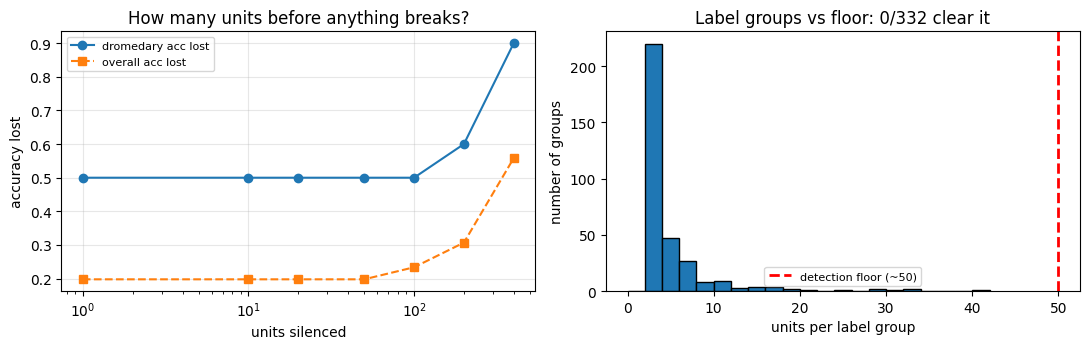

In [43]:
import matplotlib.pyplot as plt

sizes = pd.Series([len(u) for u in word_groups.values()])
print(f"Label groups: {len(sizes)} groups, {sizes.sum()} units")
print(f"  mean {sizes.mean():.1f} | median {sizes.median():.0f} | max {sizes.max()}")
print(f"  groups with >= 50 units: {(sizes >= 50).sum()} / {len(sizes)}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(dose.n_units, dose.ctrl_acc_drop, "o-", label=f"{classnames[CTRL]} acc lost")
ax[0].plot(dose.n_units, dose.overall_drop, "s--", label="overall acc lost")
ax[0].set_xscale("log"); ax[0].set_xlabel("units silenced"); ax[0].set_ylabel("accuracy lost")
ax[0].set_title("How many units before anything breaks?")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].hist(sizes, bins=np.arange(0, sizes.max()+3, 2), edgecolor="black")
ax[1].axvline(50, color="red", ls="--", lw=2, label="detection floor (~50)")
ax[1].set_xlabel("units per label group"); ax[1].set_ylabel("number of groups")
ax[1].set_title(f"Label groups vs floor: {(sizes>=50).sum()}/{len(sizes)} clear it")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS / "figures" / "detection_floor_vs_group_size.png", dpi=120, bbox_inches="tight")
plt.show()

Damage climbs with group size and the overall drop climbs alongside it — by 400 units the
network as a whole has lost 0.56 accuracy, so at that point you're not testing a concept any
more, you're just breaking the model. There's a window in between: big enough to get past the
redundancy, small enough that the damage still means something.

The label groups never reach it. 332 groups, 1,496 units, mean of 4.5 units each, largest 41 —
**not one of them hits 50**. So the near-zero scores above say nothing about label quality. The
measurement was below what the instrument can resolve.

In [49]:
CONCEPTS = ["dog", "cat", "bird", "flower", "texture"]
FAMILY_TOPK = 60

concept_emb = {}
for cpt in CONCEPTS:
    with torch.no_grad():
        t = clip_tok([f"a photo of a {cpt}"]).to(device)
        concept_emb[cpt] = torch.nn.functional.normalize(
            clip_model.encode_text(t), dim=-1).cpu().numpy()[0]

results = []
for cpt in CONCEPTS:
    ce = concept_emb[cpt]
    unit_sim, class_sim = unitlabel_emb @ ce, class_emb @ ce
    family = np.argsort(-class_sim)[:FAMILY_TOPK]
    others = np.setdiff1d(np.arange(1000), family)
    print(f"\n=== {cpt.upper()} ===  family: {', '.join(classnames[i] for i in family[:6])}, ...")
    for Nn in [50, 100, 200]:
        idx = np.argsort(-unit_sim)[:Nn]
        d = damage([unit_order[j] for j in idx])
        fam, oth = d[family].mean(), d[others].mean()
        results.append({"concept": cpt, "N": Nn, "mean_label_sim": unit_sim[idx].mean(),
                        "family_damage": fam, "other_damage": oth,
                        "specificity": fam / max(oth, 1e-6)})
        print(f"  N={Nn:>3} | lbl-sim {unit_sim[idx].mean():.3f} | family {fam:+.4f} | "
              f"other {oth:+.4f} | specificity {fam/max(oth,1e-6):.2f}x", flush=True)

dfC = pd.DataFrame(results)
dfC.to_json(RESULTS / "scores" / "concept_pool_doing.json", orient="records", indent=1)
display(dfC.round(4))


=== DOG ===  family: collie, Labrador Retriever, Chihuahua, pig, husky, lion, ...
  N= 50 | lbl-sim 0.919 | family +0.1017 | other +0.0516 | specificity 1.97x
  N=100 | lbl-sim 0.890 | family +0.1733 | other +0.0948 | specificity 1.83x
  N=200 | lbl-sim 0.847 | family +0.3217 | other +0.2398 | specificity 1.34x

=== CAT ===  family: tabby cat, tiger cat, Persian cat, tiger, lion, Siamese cat, ...
  N= 50 | lbl-sim 0.909 | family +0.0783 | other +0.0555 | specificity 1.41x
  N=100 | lbl-sim 0.859 | family +0.1367 | other +0.1141 | specificity 1.20x
  N=200 | lbl-sim 0.814 | family +0.2283 | other +0.1945 | specificity 1.17x

=== BIRD ===  family: duck, hummingbird, hen, cock, bald eagle, goose, ...
  N= 50 | lbl-sim 0.804 | family +0.0333 | other +0.0283 | specificity 1.18x
  N=100 | lbl-sim 0.787 | family +0.1200 | other +0.0997 | specificity 1.20x
  N=200 | lbl-sim 0.766 | family +0.3267 | other +0.3118 | specificity 1.05x

=== FLOWER ===  family: daisy, bee, vase, rifle, banana, str

,concept,N,mean_label_sim,family_damage,other_damage,specificity
0,dog,50,0.9188,0.1017,0.0516,1.9704
1,dog,100,0.8897,0.1733,0.0948,1.8287
2,dog,200,0.8474,0.3217,0.2398,1.3415
3,cat,50,0.9091,0.0783,0.0555,1.4106
4,cat,100,0.8589,0.1367,0.1141,1.1973
5,cat,200,0.8138,0.2283,0.1945,1.1741
6,bird,50,0.8041,0.0333,0.0283,1.1779
7,bird,100,0.7869,0.1200,0.0997,1.2038
8,bird,200,0.7656,0.3267,0.3118,1.0477
9,flower,50,0.8669,0.0433,0.0499,0.8685


Specificity divides damage inside a concept's class family by damage outside it, so it's only as
good as that family. The automatic version isn't good — CLIP's top-60 "dog" family included pig
and lion, and its "flower" family included rifle and banana.

ImageNet's dog breeds sit in one contiguous block (151–268, 118 breeds), so that ground truth
can be checked by hand. Birds are spread over three ranges but are equally verifiable.

In [50]:
dog_family = np.arange(151, 269)
others = np.setdiff1d(np.arange(1000), dog_family)
ce = concept_emb["dog"]
for Nn in [50, 100, 200]:
    pool = [unit_order[j] for j in np.argsort(-(unitlabel_emb @ ce))[:Nn]]
    d = damage(pool)
    print(f"N={Nn:>3} | family {d[dog_family].mean():+.4f} | other {d[others].mean():+.4f} "
          f"| specificity {d[dog_family].mean()/d[others].mean():.2f}x", flush=True)

N= 50 | family +0.1551 | other +0.0412 | specificity 3.77x
N=100 | family +0.2712 | other +0.0765 | specificity 3.54x
N=200 | family +0.4593 | other +0.2160 | specificity 2.13x


In [51]:
bird_family = np.concatenate([np.arange(7, 25), np.arange(80, 101), np.arange(127, 147)])
others = np.setdiff1d(np.arange(1000), bird_family)
ce = concept_emb["bird"]
for Nn in [50, 100, 200]:
    pool = [unit_order[j] for j in np.argsort(-(unitlabel_emb @ ce))[:Nn]]
    d = damage(pool)
    print(f"N={Nn:>3} | family {d[bird_family].mean():+.4f} | other {d[others].mean():+.4f} "
          f"| specificity {d[bird_family].mean()/d[others].mean():.2f}x", flush=True)

N= 50 | family +0.0542 | other +0.0270 | specificity 2.01x
N=100 | family +0.2051 | other +0.0944 | specificity 2.17x
N=200 | family +0.4627 | other +0.3033 | specificity 1.53x



Once the pools are large enough to test, the labels carry real causal information. Silencing the
50 most dog-labelled units costs dog classes nearly four times as much accuracy as everything
else (3.77×), and the effect fades as the pool loosens which is what you'd expect if it's real rather than an artefact of size. Birds behave the same
way at a lower level: 2.01× at 50 units, 1.53× by 200.

The class family matters enormously. With CLIP's automatic top-60 families, dog scored 1.97× and
bird 1.18×; with hand-verified ImageNet families — the 118-breed dog block and the three bird
ranges — the same pools score 3.77× and 2.01×. CLIP's "dog" family had pig and lion in it and
its "flower" family had rifle and banana, and that contamination roughly halves the measured
effect. Every specificity computed from an automatic family should be read as a lower bound.

The remaining concepts can't be tested properly. Cat and flower have four ImageNet classes each,
so their damage is averaged over too few classes to be stable, and texture has no class family
at all, it's included as a negative control and behaves like one, sitting below 1.

So the doing test gives a conditional answer. Where a concept is well enough represented, enough
units to overcome the redundancy, enough classes to measure against, its labels hold up
causally, and hold up strongly. Where it isn't, the question can't be answered with this method,
and most of the 332 label groups fall in that second category.